# Custom objectives and constraints

Every keyword on a `JuMPOptimiser` — bounds, budgets, turnover, fees, cardinality —
is a *pre-built* way to shape the problem. When a mandate needs something none of them covers,
`PortfolioOptimisers.jl` gives you two extension points that write **straight against the JuMP
model**:

  - `CustomJuMPObjective` (the `cobj` keyword) — implement
    `add_custom_objective_term!` to *price* a preference, softly.
  - `CustomJuMPConstraint` (the `ccnt` keyword) — implement
    `add_custom_constraint!` to *mandate* one, hard.

Each keyword takes a single estimator *or a vector of them*, and each hook **dispatches on the
estimator's type**, so a term is just a struct carrying its data plus one method. Subtyping one
without implementing its method is an error, not a silent no-op. This page builds both from
scratch, works through the model idioms that keep them correct (the constraint scale and the
homogenisation variable `k`), and composes several into one problem. It is the deep dive behind the one-call summary in the
[constraints & costs guide](../../user_guide/03_Constraints_and_Costs.md).

> **When to reach for this**
>
> Reach for a custom term when your preference is a **continuous per-asset number** that no
> group string can express — a factor score, a carbon intensity, a liquidity penalty — or a
> relationship between weights that isn't a plain linear bound. If it *can* be written as a
> linear/group constraint (`lcse`) or an existing keyword, prefer that: the built-ins are
> tested and composable. Custom hooks are the escape hatch, not the first tool.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes
using JuMP: JuMP

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. Data and a momentum score

We fix one empirical prior, a solver, and a minimum-risk baseline, so every custom term's
effect is visible against the same allocation. The preference we will encode is a **momentum
score**: each asset's trailing-63-day return, standardised across the universe. It is a
continuous per-asset number — exactly the case the extension points exist for.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

score = let m = vec(sum(rd.X[(end - 62):end, :]; dims = 1))
    (m .- mean(m)) ./ std(m)
end

res_base = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

The portfolio's **momentum exposure** is `score' * w` — the score-weighted allocation. The
minimum-risk baseline does not care about momentum, so it lands wherever the risk trade-off
puts it; we will push that exposure up, first softly (an objective), then hard (a constraint).

In [3]:
base_exposure = score' * res_base.w

0.2042109183638675

## 2. A custom objective — a soft tilt

A custom objective is a struct subtyping `CustomJuMPObjective`, carrying whatever data
the term needs, plus one method of `add_custom_objective_term!`. The method is handed
the model *mid-assembly* and contributes a term to the **objective penalty**. Its signature is

```julia
add_custom_objective_term!(model, obj, cobj, optimiser, attrs)
```

  - `model` — the [`JuMP`](https://jump.dev/) model under construction.
  - `obj` — the `ObjectiveFunction` being built (`MinimumRisk`, `MaximumUtility`, …).
    Dispatch on this if your term should *differ* by objective; you do **not** need it to get
    the sign right.
  - `cobj` — your estimator; the argument you dispatch your method on.
  - `optimiser` — the outer optimiser estimator (e.g. the `MeanRisk` itself). Its `opt`
    field is the `JuMPOptimiser`.
  - `attrs` — the `ProcessedJuMPOptimiserAttributes` bundle: `attrs.pr` (prior),
    `attrs.ret` (returns estimator), `attrs.wb` (bounds) and the rest of the processed problem
    data, if your term is data-driven rather than carrying its own numbers.

Read the weight variables with the `get_w` accessor rather than reaching into
`model[:w]` — it asserts the variables have been registered and fails with a clear message if a
hook runs out of order.

Contribute the term with `add_to_objective_penalty!` rather than touching the objective
expression yourself. That single call is what makes the term correct everywhere:

> **The library orients your term; you just say what you mean**
>
> Some objectives are minimised and some maximised, and `MaximumRatio` is *either*
> depending on the risk measure — so a term written against the raw objective expression needs
> a sign that no single rule can supply. The penalty accumulator sidesteps this: it is folded
> into the objective with the factor matching whichever sense is being built, so **a
> contribution always worsens the objective, and a reward is a negative contribution**. Write
> `-λ * something_good` once and it rewards under every objective.

    It also promotes an affine accumulator to a quadratic one as needed, so a quadratic term
    (an L2 tilt, a tracking penalty) is safe against any objective — including the affine ones,
    where mutating the expression directly would be a `MethodError`.

In [4]:
struct MomentumTilt{T1, T2} <: PortfolioOptimisers.CustomJuMPObjective
    score::T1
    lambda::T2
end

function PortfolioOptimisers.add_custom_objective_term!(model::JuMP.Model, obj,
                                                        cobj::MomentumTilt, optimiser,
                                                        attrs)
    w = PortfolioOptimisers.get_w(model)
    # Negative penalty == reward. No sign dispatch, no objective-type special cases.
    PortfolioOptimisers.add_to_objective_penalty!(model, -cobj.lambda * (cobj.score' * w))
    return nothing
end

`lambda` is the price we put on momentum relative to risk. Sweeping it traces the *soft*
trade-off: a small `lambda` barely moves the book, a large one lets momentum dominate — until
the term saturates and the portfolio piles into the single highest-momentum name.

In [5]:
lambdas = [0.0, 1e-4, 5e-4, 2e-3]
tilt_res = [optimise(MeanRisk(; obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                  cobj = MomentumTilt(score, l))))
            for l in lambdas]

pretty_table(DataFrame("λ (momentum price)" => lambdas,
                       "Momentum exposure" => [score' * r.w for r in tilt_res],
                       "Max weight" => [maximum(r.w) for r in tilt_res]);
             formatters = [resfmt],
             title = "A larger λ buys more momentum exposure, until it saturates")

A larger λ buys more momentum exposure, until it saturates
┌────────────────────┬───────────────────┬────────────┐
│ λ (momentum price) │ Momentum exposure │ Max weight │
│            Float64 │           Float64 │    Float64 │
├────────────────────┼───────────────────┼────────────┤
│                0.0 │          20.421 % │   36.974 % │
│             0.0001 │         129.535 % │   69.305 % │
│             0.0005 │         139.637 % │   83.008 % │
│              0.002 │         139.873 % │   88.846 % │
└────────────────────┴───────────────────┴────────────┘


Note the term is **homogeneous of degree one in `w`** (it scales with the weights, just like the
return and risk expressions). That is what lets it stay consistent under a ratio objective's
internal rescaling — the constraint side, next, is where that rescaling needs explicit care.

## 3. The same term under a different sense

`MaximumUtility` is a *maximisation*, the exact opposite of the minimisation above — and the
tilt needs no change at all. The identical `MomentumTilt` lifts its momentum exposure too,
because the penalty accumulator is folded in with the factor for whichever sense is being built.

In [6]:
util_base = optimise(MeanRisk(; obj = MaximumUtility(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv)))
util_tilt = optimise(MeanRisk(; obj = MaximumUtility(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                  cobj = MomentumTilt(score, 5e-3))))

util_exposures = (base = score' * util_base.w, tilted = score' * util_tilt.w)

(base = 1.15610715381599, tilted = 1.403239633609198)

> **`MaximumRatio` needs no special case**
>
> The maximum-ratio problem is solved through a homogenising transform that, depending on the
> risk measure, lands the objective in **either** a maximisation **or** a risk-minimisation
> form — so a term written against the raw objective expression has no single correct sign.
> Because the contribution goes through the penalty accumulator, both forms fold it in with
> their own factor and the tilt rewards momentum either way. Note this fixes the *sign*, not
> the *scaling*: §5's `k` idiom still applies to any term that is not homogeneous of degree
> one in `w`.

## 4. A custom constraint — a hard floor

A custom constraint is the same shape: a struct subtyping `CustomJuMPConstraint` plus
one method of `add_custom_constraint!`, whose signature is

```julia
add_custom_constraint!(model, ccnt, optimiser, attrs)
```

  - `model`, `optimiser`, `attrs` — exactly as on the objective side (`ccnt` is what you
    dispatch on). The two hooks take the same arguments; the objective one adds `obj` ahead of
    the dispatch argument, and that is the only difference between them.

Two model idioms keep a hand-written constraint correct (see ADR 0008, *JuMP model assembly*):

 1. **Scale the constraint** by `get_constraint_scale` (`model[:sc]`), so it sits on the
    same numerical footing as every built-in constraint.
 2. **Multiply any constant bound by `get_k`** (`model[:k]`), the homogenisation
    variable. For most objectives `k == 1` and this is a no-op; under a ratio objective the
    weights are solved in a rescaled space (`w_real = w / k`), and a bare constant would be
    compared against the *rescaled* weights — the wrong thing. §5 shows exactly what breaks.

In [7]:
struct MomentumFloor{T1, T2} <: PortfolioOptimisers.CustomJuMPConstraint
    score::T1
    floor::T2
end

function PortfolioOptimisers.add_custom_constraint!(model::JuMP.Model, ccnt::MomentumFloor,
                                                    optimiser, attrs)
    w = PortfolioOptimisers.get_w(model)
    k = PortfolioOptimisers.get_k(model)
    sc = PortfolioOptimisers.get_constraint_scale(model)
    JuMP.@constraint(model, sc * (ccnt.score' * w - ccnt.floor * k) >= 0)
    return nothing
end

Unlike the soft tilt, a floor binds *exactly*: the optimiser buys just enough momentum to meet
it and no more, spending the rest of its freedom on risk. Sweeping the floor shows it clamping
the exposure to the requested level (a floor below the baseline `0.204` simply never binds).

In [8]:
floors = [0.0, 0.5, 1.0, 1.35]
floor_res = [optimise(MeanRisk(; obj = MinimumRisk(),
                               opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                   ccnt = MomentumFloor(score, f))))
             for f in floors]

pretty_table(DataFrame("Momentum floor" => floors,
                       "Momentum exposure" => [score' * r.w for r in floor_res],
                       "Binds?" => [score' * r.w > f + 1e-6 ? "no" : "yes"
                                    for (f, r) in zip(floors, floor_res)]);
             formatters = [resfmt], title = "A hard floor clamps the exposure to its bound")

 A hard floor clamps the exposure to its bound
┌────────────────┬───────────────────┬────────┐
│ Momentum floor │ Momentum exposure │ Binds? │
│        Float64 │           Float64 │ String │
├────────────────┼───────────────────┼────────┤
│            0.0 │          20.436 % │     no │
│            0.5 │            50.0 % │     no │
│            1.0 │           100.0 % │    yes │
│           1.35 │           135.0 % │    yes │
└────────────────┴───────────────────┴────────┘


## 5. Why the `k` idiom matters

To see idiom (2) pay off, here is the *same* floor written **without** the `* k` — the mistake
most people make first, because it is invisible under `MinimumRisk` (where `k == 1`).

In [9]:
struct MomentumFloorNoK{T1, T2} <: PortfolioOptimisers.CustomJuMPConstraint
    score::T1
    floor::T2
end
function PortfolioOptimisers.add_custom_constraint!(model::JuMP.Model,
                                                    ccnt::MomentumFloorNoK, opt, attrs)
    w = PortfolioOptimisers.get_w(model)
    sc = PortfolioOptimisers.get_constraint_scale(model)
    JuMP.@constraint(model, sc * (ccnt.score' * w - ccnt.floor) >= 0)  # forgot `* k`
    return nothing
end

Under `MaximumRatio` the homogenisation variable `k` is a genuine free variable, so the
two versions diverge. The correct floor binds the *recovered* exposure exactly at the bound; the
`k`-less one binds it at some fixed level of the rescaled weights — which, at `floor = 1.38`,
lands **below** the requested floor, silently breaking the mandate.

In [10]:
k_floors = [1.30, 1.35, 1.38]
k_compare = [(f,
              score' * optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                                         opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                             ccnt = MomentumFloor(score, f)))).w,
              score' * optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                                         opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                             ccnt = MomentumFloorNoK(score, f)))).w)
             for f in k_floors]

pretty_table(DataFrame("Requested floor" => first.(k_compare),
                       "With * k (correct)" => getindex.(k_compare, 2),
                       "Without * k (wrong)" => getindex.(k_compare, 3));
             formatters = [resfmt],
             title = "Under a ratio objective, only the k-scaled floor binds where asked")

Under a ratio objective, only the k-scaled floor binds where asked
┌─────────────────┬────────────────────┬─────────────────────┐
│ Requested floor │ With * k (correct) │ Without * k (wrong) │
│         Float64 │            Float64 │             Float64 │
├─────────────────┼────────────────────┼─────────────────────┤
│             1.3 │            130.0 % │           136.853 % │
│            1.35 │            135.0 % │           136.933 % │
│            1.38 │            138.0 % │           136.983 % │
└─────────────────┴────────────────────┴─────────────────────┘


## 6. Composing several custom pieces

Both keywords accept a **vector** of estimators, applied in order — the hooks iterate and
dispatch each element. That is how you stack custom terms without folding them into one struct.

**A band from two constraints.** Pair the floor with its mirror image — a cap, the same idiom
with the inequality flipped — and the two together bound the exposure into a corridor. Define
the cap first (as always, every custom type before the optimiser that uses it):

In [11]:
struct MomentumCap{T1, T2} <: PortfolioOptimisers.CustomJuMPConstraint
    score::T1
    cap::T2
end
function PortfolioOptimisers.add_custom_constraint!(model::JuMP.Model, ccnt::MomentumCap,
                                                    optimiser, attrs)
    w = PortfolioOptimisers.get_w(model)
    k = PortfolioOptimisers.get_k(model)
    sc = PortfolioOptimisers.get_constraint_scale(model)
    JuMP.@constraint(model, sc * (ccnt.cap * k - ccnt.score' * w) >= 0)
    return nothing
end

band = optimise(MeanRisk(; obj = MinimumRisk(),
                         opt = JuMPOptimiser(; pe = pr, slv = slv,
                                             ccnt = [MomentumFloor(score, 0.5),
                                                     MomentumCap(score, 0.8)])))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

**Additive objectives.** A `cobj` vector contributes each term to the same penalty accumulator,
so two `1e-4` tilts compose into one of strength `2e-4` — a quick sanity check that vectors
accumulate rather than replace:

In [12]:
two_tilts = optimise(MeanRisk(; obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                  cobj = [MomentumTilt(score, 1e-4),
                                                          MomentumTilt(score, 1e-4)])))
one_double = optimise(MeanRisk(; obj = MinimumRisk(),
                               opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                   cobj = MomentumTilt(score, 2e-4))))

composition = (band = score' * band.w, two_1e4_tilts = score' * two_tilts.w,
               one_2e4_tilt = score' * one_double.w)

(band = 0.5000014186440694, two_1e4_tilts = 1.3694760110199082, one_2e4_tilt = 1.3694760110199082)

The band sits inside `[0.5, 0.8]`, and the two stacked tilts land on exactly the same exposure
as the single double-strength tilt — vectors compose.

**Objective and constraint together.** Nothing stops you mixing them: a soft tilt *and* a hard
floor in the same problem, each through its own keyword.

In [13]:
res_both = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                 cobj = MomentumTilt(score, 1e-4),
                                                 ccnt = MomentumFloor(score, 1.0))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

## 7. Comparing the effect

Same prior, same minimum-risk objective — only the custom term changes the allocation. The soft
tilt leans toward momentum as far as the risk trade-off allows; the hard floor and the band pin
the exposure to a level; combining them does both.

                        Weights under each custom term
┌────────┬──────────┬─────────────┬───────────┬────────────────┬──────────────┐
│  Asset │     Base │ Tilt λ=1e-4 │ Floor 1.0 │ Band [0.5,0.8] │ Tilt + floor │
│ String │  Float64 │     Float64 │   Float64 │        Float64 │      Float64 │
├────────┼──────────┼─────────────┼───────────┼────────────────┼──────────────┤
│   AAPL │    0.0 % │      -0.0 % │     0.0 % │          0.0 % │       -0.0 % │
│    AMD │    0.0 % │      -0.0 % │     0.0 % │          0.0 % │       -0.0 % │
│    BAC │    0.0 % │       0.0 % │     0.0 % │          0.0 % │       -0.0 % │
│    BBY │    0.0 % │     1.296 % │     0.0 % │          0.0 % │      1.297 % │
│    CVX │  7.432 % │     5.704 % │    9.46 % │        8.072 % │      5.705 % │
│     GE │  0.806 % │     9.022 % │   4.274 % │        1.997 % │       9.02 % │
│     HD │    0.0 % │       0.0 % │     0.0 % │          0.0 % │        0.0 % │
│    JNJ │ 36.974 % │       0.0 % │   0.001 % │       23.868 % │ 

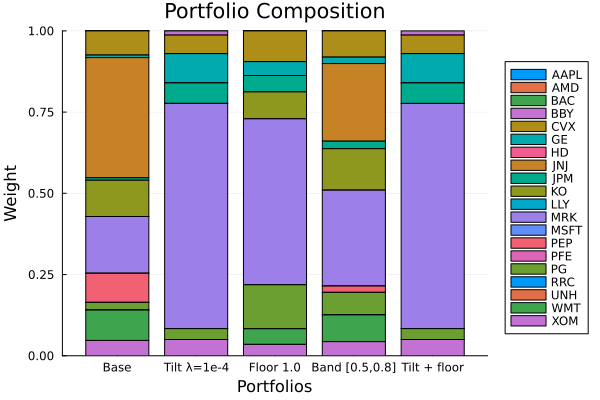

In [14]:
results = [res_base, tilt_res[2], floor_res[3], band, res_both]
labels = ["Base", "Tilt λ=1e-4", "Floor 1.0", "Band [0.5,0.8]", "Tilt + floor"]

pretty_table(DataFrame(["Asset" => rd.nx,
                        [labels[i] => results[i].w for i in eachindex(results)]...]);
             formatters = [resfmt], title = "Weights under each custom term")

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*